In [18]:
import numpy as np
import matplotlib.pylab as plt
import sys
sys.path.append("..")

### 2D nodal --> modal

p = 3, exact polynomial degree = 3
nodal inverse max err: 6.661338147750939e-16
nodal inverse rel err: 4.043274642199629e-16
grid eval max err    : 7.771561172376096e-16
grid eval rel err    : 4.565324228973921e-16


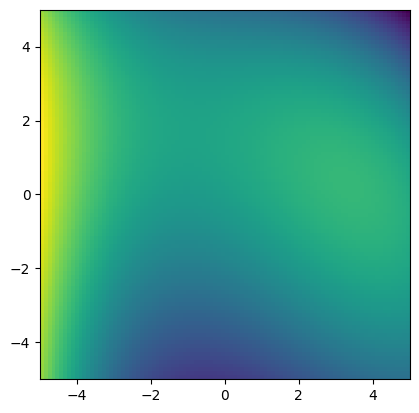

In [19]:
from src.dg_nodal_transform import nodal_image_to_dg, dg_modal_to_nodal_image
from src.dg_utils import eval_dg_modal_on_img_grid, build_image_grid

def exact_poly2d_scaled(x, y, degree=4, xlim=(-1,1), ylim=(-1,1)):
    x = np.asarray(x)
    y = np.asarray(y)

    # map to [-1,1]
    xhat = 2*(x - xlim[0])/(xlim[1] - xlim[0]) - 1
    yhat = 2*(y - ylim[0])/(ylim[1] - ylim[0]) - 1

    poly = 0.1 * np.ones_like(xhat)

    if degree >= 1:
        poly += 0.3*xhat - 0.4*yhat
    if degree >= 2:
        poly += 0.5*xhat**2 + 0.2*xhat*yhat - 0.6*yhat**2
    if degree >= 3:
        poly += -0.7*xhat**3 + 0.4*xhat**2*yhat - 0.3*xhat*yhat**2 + 0.2*yhat**3
    if degree >= 4:
        poly += 0.25*xhat**4 - 0.35*xhat**3*yhat + 0.15*xhat**2*yhat**2 + 0.1*xhat*yhat**3 - 0.2*yhat**4
    if degree >= 5:
        poly += -0.1*xhat**5 + 0.08*xhat**4*yhat - 0.06*xhat**3*yhat**2 + 0.04*xhat**2*yhat**3 - 0.02*xhat*yhat**4 + 0.05*yhat**5

    return poly

##### Roundtrip check for DG #####

### setup
xmin, xmax = -5, 5
ymin, ymax = -5, 5
xlim = (xmin, xmax)
ylim = (ymin, ymax)

### DG stuff
Kx, Ky = 24, 24
p = 3
Nx, Ny = Kx * (p + 1), Ky * (p + 1)

xgrid, ygrid, dx, dy = build_image_grid(
    DOF_x=Nx, DOF_y=Ny,
    xlim=(xmin, xmax), ylim=(ymin, ymax)
)

X, Y = np.meshgrid(xgrid, ygrid, indexing="xy")

exact_poly_deg = p       # needs to be p for machine precision for DG

print(f"p = {p}, exact polynomial degree = {exact_poly_deg}")

exact_data = exact_poly2d_scaled(x=X, y=Y, degree=exact_poly_deg, xlim=xlim, ylim=ylim)

arr = exact_data.copy()

dg = nodal_image_to_dg(arr, xlim=(xmin, xmax), ylim=(ymin, ymax), deg=p)

arr_rec1 = dg_modal_to_nodal_image(dg)
arr_rec2 = eval_dg_modal_on_img_grid(dg)

print("nodal inverse max err:", np.max(np.abs(arr_rec1 - arr)))
print("nodal inverse rel err:", np.linalg.norm(arr_rec1 - arr) / np.linalg.norm(arr))

print("grid eval max err    :", np.max(np.abs(arr_rec2 - arr)))
print("grid eval rel err    :", np.linalg.norm(arr_rec2 - arr) / np.linalg.norm(arr))

plt.imshow(exact_data, extent=[xmin, xmax, ymin, ymax])

In [20]:
from src.siac_modal import apply_siac_modal_dg

moments = 2
BSorder = 1
arr_rec3 = apply_siac_modal_dg(dg, moments=moments, BSorder=BSorder)

halfker = int(np.ceil((moments + BSorder) / 2)) + 1

trim = halfker * (p + 1)
sl_y = slice(trim, -trim)
sl_x = slice(trim, -trim)

print("SIAC max err (internal):", np.max(np.abs(arr_rec3[sl_y, sl_x] - arr[sl_y, sl_x])))
print("SIAC rel err (internal):", np.linalg.norm(arr_rec3[sl_y, sl_x] - arr[sl_y, sl_x]) / np.linalg.norm(arr[sl_y, sl_x]))


SIAC max err (internal): 6.661338147750939e-16
SIAC rel err (internal): 8.270657915288718e-16


In [21]:

def add_noise_to_data(exact_data, hx, hy, p, sigma_scale=1.0, seed=62):
    """
    Add noise to the exact function exact_func.
    hx - element spacing x
    hy - element spacing y
    p - DG polynomial basis degree
    basic: noise of level h**(p+1), h = sqrt(hx^2 + hy^2), characteristic length of mesh
    """
    rng = np.random.default_rng(seed)
    
    h = np.sqrt(hx**2 + hy**2)
    pw = p+1
    sigma = h ** pw
    
    noise = rng.standard_normal(size=exact_data.shape) * sigma * sigma_scale
    
    # print(f"[noise] h={h:.3e}, sigma={sigma:.3e} (h^{pw})")
    # rel_noise = np.linalg.norm(noise) / np.linalg.norm(exact_data)
    # print(f"[rel.noise] rel_noise={rel_noise:.3e}")
    
    return exact_data + noise


### Pointwise error on fine grid

In [22]:
from src.dg_nodal_transform import nodal_image_to_dg
from src.dg_utils import build_image_grid
from src.research_utils_2d import (
    local_cell_center_nodes_1d,
    build_grid_from_local_nodes_2d,
    eval_dg_modal_local_nodes,
    apply_siac_modal_dg_local_nodes,
    trim_valid_siac_region,
)

# -----------------------------
# 1. Problem / domain setup
# -----------------------------
xmin, xmax = -5, 5
ymin, ymax = -5, 5
xlim = (xmin, xmax)
ylim = (ymin, ymax)

# DG polynomial degree
p = 5

# DG mesh resolution
Kx, Ky = 12, 12
Nx, Ny = Kx * (p + 1), Ky * (p + 1)

# SIAC parameters
moments = 4
BSorder = 3

# exact polynomial degree for testing
exact_poly_deg = 5

# -----------------------------
# 2. Build original image grid
# -----------------------------
xgrid, ygrid, dx, dy = build_image_grid(
    DOF_x=Nx,
    DOF_y=Ny,
    xlim=xlim,
    ylim=ylim
)

X, Y = np.meshgrid(xgrid, ygrid, indexing="xy")

exact_data = exact_poly2d_scaled(
    x=X,
    y=Y,
    degree=exact_poly_deg,
    xlim=xlim,
    ylim=ylim
)

# -----------------------------
# 3. Build DG representation
# -----------------------------
dg = nodal_image_to_dg(
    exact_data,
    xlim=xlim,
    ylim=ylim,
    deg=p
)

# -----------------------------
# 4. Fine local nodes per element
# -----------------------------
n_eval = 8 * (p + 1)
nodes_fine = local_cell_center_nodes_1d(n_eval)

# -----------------------------
# 5. Build global fine grid
# -----------------------------
X_fine, Y_fine = build_grid_from_local_nodes_2d(
    dg["mesh"],
    nodes_fine
)

# -----------------------------
# 6. Evaluate exact, DG, SIAC
# -----------------------------
exact_data_fine = exact_poly2d_scaled(
    x=X_fine,
    y=Y_fine,
    degree=exact_poly_deg,
    xlim=xlim,
    ylim=ylim
)

dg_fine = eval_dg_modal_local_nodes(
    dg,
    eval_nodes=nodes_fine
)

siac_fine = apply_siac_modal_dg_local_nodes(
    dg,
    moments=moments,
    BSorder=BSorder,
    eval_nodes=nodes_fine
)

# -----------------------------
# 7. Trim interior for SIAC comparison
# -----------------------------
n_eval = len(nodes_fine)

exact_trim, trim = trim_valid_siac_region(
    exact_data_fine,
    n_eval=n_eval,
    moments=moments,
    BSorder=BSorder,
    safety_pad=False
)

dg_trim, _ = trim_valid_siac_region(
    dg_fine,
    n_eval=n_eval,
    moments=moments,
    BSorder=BSorder,
    safety_pad=False
)

siac_trim, _ = trim_valid_siac_region(
    siac_fine,
    n_eval=n_eval,
    moments=moments,
    BSorder=BSorder,
    safety_pad=False
)

# -----------------------------
# 8. Errors
# -----------------------------
err_dg = dg_trim - exact_trim
err_siac = siac_trim - exact_trim

print("trim =", trim)

print("DG max err   :", np.max(np.abs(err_dg)))
print("DG rel err   :", np.linalg.norm(err_dg) / np.linalg.norm(exact_trim))

print("SIAC max err :", np.max(np.abs(err_siac)))
print("SIAC rel err :", np.linalg.norm(err_siac) / np.linalg.norm(exact_trim))

trim = 192
DG max err   : 2.0816681711721685e-15
DG rel err   : 1.0318599313890426e-15
SIAC max err : 1.3877787807814457e-15
SIAC rel err : 1.387682717989336e-15


### Convergence study

In [23]:
def convergence_study_dg_siac_2d(
    exact_fun,
    K_values,
    p,
    xlim=(-1, 1),
    ylim=(-1, 1),
    fine_factor=8,
    moments=None,
    BSorder=None,
    add_noise=False,
    exact_fun_kwargs=None,
):
    if moments is None:
        moments = 2 * p
    if BSorder is None:
        BSorder = p + 1
    if exact_fun_kwargs is None:
        exact_fun_kwargs = {}

    K_values = np.asarray(K_values, dtype=int)

    K_list = []
    h_list = []

    dg_max_list = []
    dg_rel_l2_list = []

    siac_max_list = []
    siac_rel_l2_list = []

    # Check refinement pattern
    assert np.all(K_values[1:] == 2 * K_values[:-1]), \
        "K_values must double each step, e.g. [8,16,32,64]"

    Kmax = np.max(K_values)

    # Fixed global evaluation resolution per direction
    N_eval_global = Kmax * fine_factor * (p + 1)

    for K in K_values:
        Kx = Ky = int(K)
        Nx = Kx * (p + 1)
        Ny = Ky * (p + 1)

        # Original image grid
        xgrid, ygrid, dx, dy = build_image_grid(
            DOF_x=Nx,
            DOF_y=Ny,
            xlim=xlim,
            ylim=ylim,
        )
        X, Y = np.meshgrid(xgrid, ygrid, indexing="xy")

        # Exact data on original grid
        exact_data = exact_fun(X, Y, xlim=xlim, ylim=ylim, **exact_fun_kwargs)

        data_for_dg = exact_data.copy()
        # optional add noise
        if add_noise == True:
            hx = (xlim[1] - xlim[0]) / Kx
            hy = (ylim[1] - ylim[0]) / Ky
            data_for_dg = add_noise_to_data(exact_data=exact_data, hx=hx, hy=hy, p=p)
            
        # Build DG representation
        dg = nodal_image_to_dg(
            data_for_dg,
            xlim=xlim,
            ylim=ylim,
            deg=p,
        )

        # Characteristic mesh size
        hx = dg["mesh"]["hx"]
        hy = dg["mesh"]["hy"]
        h = np.sqrt(hx**2 + hy**2)

        # Number of evaluation points per element
        assert N_eval_global % K == 0, \
            f"N_eval_global={N_eval_global} must be divisible by K={K}"

        n_eval = int(N_eval_global // K)
        nodes_fine = local_cell_center_nodes_1d(n_eval)

        # Global fine grid
        X_fine, Y_fine = build_grid_from_local_nodes_2d(
            dg["mesh"],
            nodes_fine,
        )

        # Exact, DG, and SIAC on same fine grid
        exact_fine = exact_fun(
            X_fine, Y_fine,
            xlim=xlim, ylim=ylim,
            **exact_fun_kwargs
        )

        dg_fine = eval_dg_modal_local_nodes(
            dg,
            eval_nodes=nodes_fine,
        )

        siac_fine = apply_siac_modal_dg_local_nodes(
            dg,
            moments=moments,
            BSorder=BSorder,
            eval_nodes=nodes_fine,
        )

        # Trim valid SIAC interior
        exact_trim, trim = trim_valid_siac_region(
            exact_fine,
            n_eval=n_eval,
            moments=moments,
            BSorder=BSorder,
            safety_pad=False,
        )
        dg_trim, _ = trim_valid_siac_region(
            dg_fine,
            n_eval=n_eval,
            moments=moments,
            BSorder=BSorder,
            safety_pad=False,
        )
        siac_trim, _ = trim_valid_siac_region(
            siac_fine,
            n_eval=n_eval,
            moments=moments,
            BSorder=BSorder,
            safety_pad=False,
        )

        # Errors
        err_dg = dg_trim - exact_trim
        err_siac = siac_trim - exact_trim

        dg_max = np.max(np.abs(err_dg))
        dg_rel_l2 = np.linalg.norm(err_dg) / np.linalg.norm(exact_trim)

        siac_max = np.max(np.abs(err_siac))
        siac_rel_l2 = np.linalg.norm(err_siac) / np.linalg.norm(exact_trim)

        # Store
        K_list.append(K)
        h_list.append(h)

        dg_max_list.append(dg_max)
        dg_rel_l2_list.append(dg_rel_l2)

        siac_max_list.append(siac_max)
        siac_rel_l2_list.append(siac_rel_l2)

    return {
        "K": np.asarray(K_list, dtype=int),
        "h": np.asarray(h_list, dtype=float),
        "dg_max": np.asarray(dg_max_list, dtype=float),
        "dg_rel_l2": np.asarray(dg_rel_l2_list, dtype=float),
        "siac_max": np.asarray(siac_max_list, dtype=float),
        "siac_rel_l2": np.asarray(siac_rel_l2_list, dtype=float),
    }

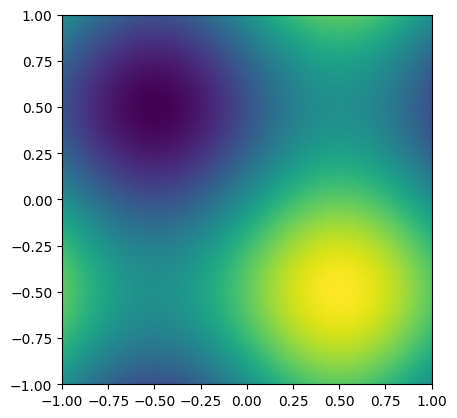

In [24]:
def exact_trig2d(x, y, xlim=(-1,1), ylim=(-1,1)):
    x = np.asarray(x)
    y = np.asarray(y)

    xhat = 2*(x - xlim[0])/(xlim[1] - xlim[0]) - 1
    yhat = 2*(y - ylim[0])/(ylim[1] - ylim[0]) - 1

    return np.sin(np.pi * xhat) + np.sin(np.pi * yhat)


xgrid_test = np.linspace(-1, 1, 201)
ygrid_test = np.linspace(-1, 1, 201)

X, Y = np.meshgrid(xgrid_test, ygrid_test, indexing="xy")
plt.imshow(exact_trig2d(X, Y, xlim=(-1,1), ylim=(-1,1)), extent=[-1, 1, -1, 1])


In [25]:

# DG stuff
p = 2

# Postprocessor
moments = 2*p
BSorder = p + 1

# grid information
xlim = (-1, 1)
ylim = (-1, 1)

# convergence information
K_values = 12 * 2**np.arange(6)
fine_factor = 2     # times more evaluation per element for the finest element construction

results = convergence_study_dg_siac_2d(
    exact_fun=exact_trig2d, 
    K_values=K_values, 
    p=p,
    xlim=xlim, 
    ylim=ylim,
    fine_factor=fine_factor, 
    moments=moments, 
    BSorder=BSorder, 
    add_noise=True
)


DG rates   : [3.42618798 2.96531388 2.9428723  2.98836994 3.07006227]
SIAC rates : [3.35540402 3.030779   2.93095166 2.98067448 2.98907257]


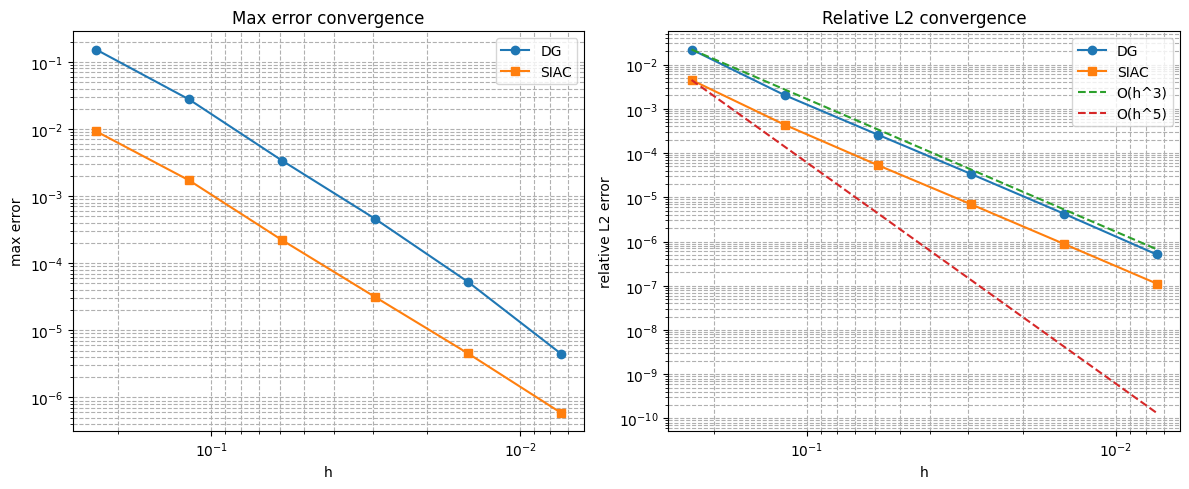

In [ ]:
hs = results["h"]
Ks = results["K"]

dg_max = results["dg_max"]
siac_max = results["siac_max"]

dg_rel_l2 = results["dg_rel_l2"]
siac_rel_l2 = results["siac_rel_l2"]

# Extract
hs = results["h"]

dg_max = results["dg_max"]
siac_max = results["siac_max"]

dg_rel_l2 = results["dg_rel_l2"]
siac_rel_l2 = results["siac_rel_l2"]

# -------------------------
# Helper: compute slopes
# -------------------------
def compute_rates(h, err):
    rates = np.log(err[:-1] / err[1:]) / np.log(h[:-1] / h[1:])
    return rates

dg_rates = compute_rates(hs, dg_rel_l2)
siac_rates = compute_rates(hs, siac_rel_l2)

print("DG rates   :", dg_rates)
print("SIAC rates :", siac_rates)


# -------------------------
# Plot
# -------------------------
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# --- Max error ---
axs[0].loglog(hs, dg_max, "o-", label="DG")
axs[0].loglog(hs, siac_max, "s-", label="SIAC")

axs[0].set_xlabel("h")
axs[0].set_ylabel("max error")
axs[0].set_title("Max error convergence")
axs[0].grid(True, which="both", ls="--")
axs[0].legend()

# --- Relative L2 ---
axs[1].loglog(hs, dg_rel_l2, "o-", label="DG")
axs[1].loglog(hs, siac_rel_l2, "s-", label="SIAC")

axs[1].set_xlabel("h")
axs[1].set_ylabel("relative L2 error")
axs[1].set_title("Relative L2 convergence")
axs[1].grid(True, which="both", ls="--")
axs[1].legend()

def add_reference_line(ax, h, err, order, label):
    c = 1.1*err[0] / (h[0]**order)
    ax.loglog(h, c * h**order, "--", label=label)

# expected DG order ~ p+1, SIAC ~ 2p+1 (roughly)

add_reference_line(axs[1], hs, dg_rel_l2, p+1, f"O(h^{p+1})")
add_reference_line(axs[1], hs, siac_rel_l2, 2*p+1, f"O(h^{2*p+1})")

axs[1].legend()

axs[0].invert_xaxis()
axs[1].invert_xaxis()
plt.tight_layout()
plt.show()

